<a href="https://colab.research.google.com/github/maheshmishraa/PortFolio_Projects/blob/main/Handwritten_Digit_Recognition_using_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Handwritten digit recognition is a classic problem in machine learning and computer vision.

It involves recognizing handwritten digits (0-9) from images or scanned documents. This task is widely used as a benchmark for evaluating machine learning models especially neural networks due to its simplicity and real-world applications such as postal code recognition and bank check processing.

In this article we will implement Handwritten Digit Recognition using Neural Network.

Let’s implement the solution step-by-step using Python and TensorFlow/Keras.

In [1]:
#STEP 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

The dataset contains 42,000 rows where each row represents an image.
The first column (label) indicates the digit (0-9) and the remaining columns represent pixel values of the image.
We separate these into X (pixel values) and y (labels).
X has 42,000 samples with 784 features (28x28 pixels) and y has 42,000 labels.

In [2]:
#STEP 2: Load and Explore Dataset
# We will load the dataset and inspect its structure to understand the features and labels.
train_data=pd.read_csv('/content/Train.csv')
print("Shape of Train_Data:",train_data.shape)
X=train_data.iloc[:,1:]
y=train_data.iloc[:,0]
print("Shape of X after separating features:",X.shape)

Shape of Train_Data: (42000, 785)
Shape of X after separating features: (42000, 784)


Raw data often needs cleaning and formatting before it can be fed into a neural network. Let’s preprocess the data to make it ready for training.

First we ensure X is in the correct format (Pandas DataFrame).
Then we convert all pixel values to numeric format and replace any missing values with 0.
Next we [normalize](https://www.geeksforgeeks.org/machine-learning/how-to-normalize-data-using-scikit-learn-in-python/) the pixel values to the range [0, 1] by dividing them by 255.0. This helps the model learn faster.
Finally we reshape the data to include a channel dimension making it compatible with neural networks.

In [3]:
#STEP 3: Preprocess the Data
if not isinstance(X,pd.DataFrame):
    X=pd.DataFrame(X)
X=X.apply(pd.to_numeric,errors='coerce')
X=X.fillna(0)
X=X.values/255.0
X=X.reshape(-1,28,28,1)
print("Shape of X after reshaping:",X.shape)

Shape of X after reshaping: (42000, 28, 28, 1)


Neural networks work best when labels are in a specific format called ["one-hot encoding."](https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/)

In [5]:
#STEP 4: One-Hot Encode the Labels
y=to_categorical(y,num_classes=10)
print("Shape of y after one-hot encoding:",y.shape)

Shape of y after one-hot encoding: (42000, 10)


To evaluate our model effectively we need to split the data into a training set and a validation set. Here we will use 80% data for training and rest
20% for testing.

In [7]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42)
print("X_train_shape: ",X_train.shape)
print("y_train_shape: ",y_train.shape)
print("X_val_shape: ",X_val.shape)
print("y_val_shape: ",y_val.shape)

X_train_shape:  (33600, 28, 28, 1)
y_train_shape:  (33600, 10)
X_val_shape:  (8400, 28, 28, 1)
y_val_shape:  (8400, 10)


Now let’s define the architecture of our neural network. We define a simple [feedforward neural network](https://www.geeksforgeeks.org/deep-learning/feedforward-neural-network/) with three layers:

A Flatten layer converts the 28x28 image into a single vector of length 784.
Two hidden layers with 128 and 64 neurons use the ReLU activation function to introduce non-linearity.
An output layer with 10 neurons uses the softmax activation function to predict probabilities for each digit (0-9).
We compile the model with the Adam optimizer, categorical cross-entropy loss, and accuracy as the evaluation metric.

In [10]:
#STEP 6: Build the Neural Network Model
from tensorflow.keras.layers import Input

model=Sequential([
    Input(shape=(28,28,1)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

With the model defined it’s time to train it on the training data. The model trains for 10 iterations (epochs) over the entire training dataset. During training it processes the data in batches of 32 samples for efficiency.

In [11]:
#STEP 7: Train the Model
history=model.fit(X_train,y_train,epochs=10,batch_size=32,validation_data=(X_val,y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9114 - loss: 0.2999 - val_accuracy: 0.9488 - val_loss: 0.1687
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9613 - loss: 0.1271 - val_accuracy: 0.9600 - val_loss: 0.1288
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9726 - loss: 0.0904 - val_accuracy: 0.9663 - val_loss: 0.1121
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9787 - loss: 0.0684 - val_accuracy: 0.9656 - val_loss: 0.1111
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9846 - loss: 0.0511 - val_accuracy: 0.9682 - val_loss: 0.1089
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9871 - loss: 0.0408 - val_accuracy: 0.9698 - val_loss: 0.1038
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9901 - loss: 0.0305 - val_accuracy: 0.9737 - val_loss: 0.1076
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9914 - loss: 0.0257 - 

Once training is complete we evaluate the model’s performance on the validation set and plot the training and validation accuracy to see how well the model learned over time. This helps us identify issues like overfitting.

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.1182
Validation Accuracy: 97.29%


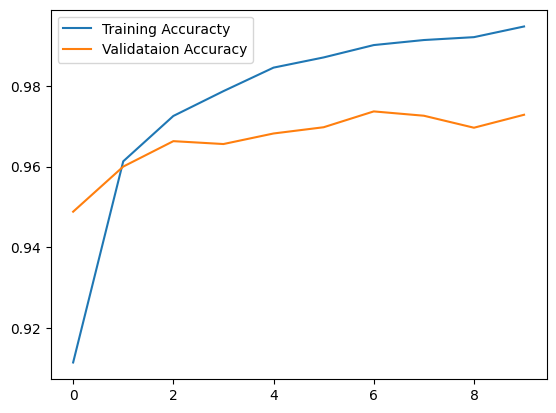

In [16]:
#STEP 8: Evaluate the Model
import matplotlib.pyplot as plt
val_loss,val_accuracy=model.evaluate(X_val,y_val)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracty')
plt.plot(history.history['val_accuracy'], label='Validataion Accuracy')
plt.legend()
plt.show()

The blue line represents the training accuracy which consistently increases over the training steps while the orange line represents the validation accuracy which fluctuates slightly but shows a positive trend. By the end of the training the model achieves a training accuracy of around 96.81% and a validation accuracy of 97.13% indicating the model performs well on both training and validation data suggesting good generalization capability.

Let’s use the trained model to make predictions on new data. We load the test data preprocess it similarly to the training data and feed it into the model to get predictions.

175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


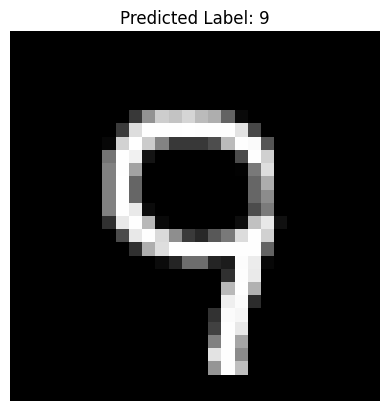

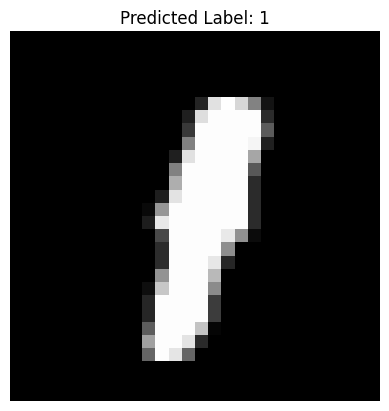

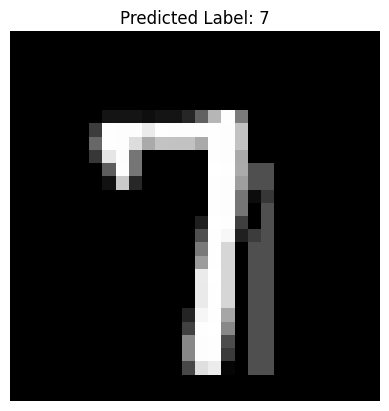

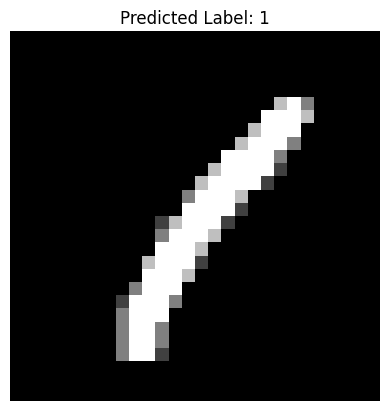

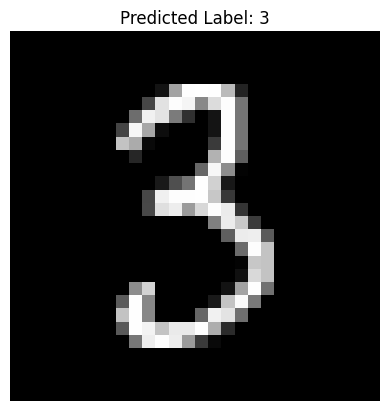

In [17]:
#STEP 9: Make Predictions
test_data=pd.read_csv('/content/test.csv')
X_test=test_data.values/255.0
X_test=X_test.reshape(-1,28,28,1)
predictions=model.predict(X_test)
predicted_labels=np.argmax(predictions,axis=1)
for i in range(5):
  plt.imshow(X_test[i].reshape(28,28),cmap='gray')
  plt.title(f"Predicted Label: {predicted_labels[i]}")
  plt.axis('off')
  plt.show()